# Tugas Besar Analisis Data — TA 2025/2026
## Analisis Korelasi dan Regresi Linier Berganda
### Indeks Pembangunan Manusia (IPM) di Indonesia

---

**Dataset:** Indeks Pembangunan Manusia (IPM) 38 Provinsi Indonesia (2023–2025)  
**Variabel Dependen (Y):** IPM (Indeks Pembangunan Manusia)  
**Variabel Independen (X):**
- **X₁ = AHH** — Angka Harapan Hidup (satuan: bulan/minggu)
- **X₂ = PDRB** — Produk Domestik Regional Bruto per kapita (ribu rupiah)
- **X₃ = Kemiskinan** — Persentase Penduduk Miskin (%)
- **X₄ = RLS** — Rata-rata Lama Sekolah (tahun)
- **X₅ = TPT** — Tingkat Pengangguran Terbuka (%)

> **Catatan:** Semua perhitungan dilakukan **secara manual** tanpa menggunakan library statistik (seperti `scipy`, `statsmodels`, atau `sklearn`). Hanya `numpy` dan `matplotlib` yang digunakan untuk operasi matriks dasar dan visualisasi.

---


## 1. Import Library dan Load Dataset

### Penjelasan
Kita hanya menggunakan:
- `numpy` → untuk operasi matriks (perkalian, transpose, invers) yang diperlukan dalam kalkulasi manual
- `matplotlib` → untuk membuat visualisasi/grafik
- `openpyxl` → untuk membaca file Excel

Library statistik seperti `scipy.stats`, `statsmodels`, atau `sklearn` **TIDAK digunakan**.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from openpyxl import load_workbook

# Pengaturan tampilan grafik
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10

print(" Library berhasil diimport!")
print(f"   NumPy version  : {np.__version__}")
print(f"   Matplotlib     : {plt.matplotlib.__version__}")


 Library berhasil diimport!
   NumPy version  : 2.0.2
   Matplotlib     : 3.10.0


## 2. Load dan Eksplorasi Data

Dataset berisi data IPM 38 Provinsi Indonesia untuk tahun 2023–2025.  
Beberapa baris memiliki nilai **Kemiskinan = None** (provinsi Papua baru), sehingga baris tersebut akan dihapus agar analisis valid.


In [ ]:
# ── Load data dari Excel ──────────────────────────────────────
wb = load_workbook('/content/dataset regresi linear berganda.xlsx', read_only=True)
ws = wb.active
rows = list(ws.iter_rows(values_only=True))

header = rows[0]
data_raw = rows[1:]

print(f"Kolom   : {header}")
print(f"Total baris mentah : {len(data_raw)}")

# ── Bersihkan baris dengan nilai None ────────────────────────
data_clean = [r for r in data_raw if all(v is not None for v in r)]
print(f"Baris setelah bersih: {len(data_clean)}")

# ── Ekstrak variabel ──────────────────────────────────────────
provinsi = [r[0] for r in data_clean]
tahun    = [r[1] for r in data_clean]
Y        = [r[2] for r in data_clean]   # IPM
AHH      = [r[3] for r in data_clean]   # X1
PDRB     = [r[4] for r in data_clean]   # X2
Kemisk   = [r[5] for r in data_clean]   # X3
RLS      = [r[6] for r in data_clean]   # X4
TPT      = [r[7] for r in data_clean]   # X5

n = len(Y)
print(f"\nJumlah observasi (n) : {n}")
print(f"Provinsi unik        : {len(set(provinsi))}")
print(f"Tahun                : {sorted(set(tahun))}")

# Konversi ke array numpy
Y_arr  = np.array(Y,      dtype=float)
X1_arr = np.array(AHH,    dtype=float)
X2_arr = np.array(PDRB,   dtype=float)
X3_arr = np.array(Kemisk, dtype=float)
X4_arr = np.array(RLS,    dtype=float)
X5_arr = np.array(TPT,    dtype=float)

print("\n── Cuplikan Data (10 baris pertama) ──")
print(f"{'No':>3} {'Provinsi':<28} {'Thn':>4} {'IPM':>6} {'AHH':>7} {'PDRB':>8} {'Miski':>6} {'RLS':>5} {'TPT':>5}")
print("-" * 75)
for i in range(10):
    print(f"{i+1:>3} {provinsi[i]:<28} {tahun[i]:>4} {Y_arr[i]:>6.2f} "
          f"{X1_arr[i]:>7.2f} {X2_arr[i]:>8.0f} {X3_arr[i]:>6.2f} "
          f"{X4_arr[i]:>5.2f} {X5_arr[i]:>5.2f}")


Kolom   : ('Provinsi', 'Tahun', 'IPM', 'AHH', 'PDRB', 'Kemiskinan', 'RLS', 'TPT')
Total baris mentah : 114
Baris setelah bersih: 102

Jumlah observasi (n) : 102
Provinsi unik        : 34
Tahun                : [2023, 2024, 2025]

── Cuplikan Data (10 baris pertama) ──
 No Provinsi                      Thn    IPM     AHH     PDRB  Miski   RLS   TPT
---------------------------------------------------------------------------
  1 ACEH                         2023  74.70  140.42    41408  41.16  9.89 11.78
  2 ACEH                         2024  75.36  140.77    41408  41.16  9.95 11.31
  3 ACEH                         2025  76.23  140.97    41408  41.16 10.42 11.14
  4 BALI                         2023  78.01  145.22    62299  13.52  9.74  6.42
  5 BALI                         2024  78.63  146.06    62299  13.52  9.87  3.66
  6 BALI                         2025  79.37  146.68    62299  13.52 10.07  3.07
  7 BANTEN                       2023  75.77  140.82    66147  18.96  9.48 15.49
  8 BAN

## 3. Statistik Deskriptif (Manual)

### Rumus yang Digunakan

**Rata-rata (Mean):**
$$\bar{X} = \frac{\sum_{i=1}^{n} X_i}{n}$$

**Simpangan Baku (Standard Deviation):**
$$s = \sqrt{\frac{\sum_{i=1}^{n}(X_i - \bar{X})^2}{n-1}}$$

**Koefisien Variasi:**
$$CV = \frac{s}{\bar{X}} \times 100\%$$


In [ ]:
# ── Fungsi statistik manual ──────────────────────────────────
def mean(arr):
    return sum(arr) / len(arr)

def variance(arr):
    mu = mean(arr)
    return sum((x - mu)**2 for x in arr) / (len(arr) - 1)

def std_dev(arr):
    return variance(arr)**0.5

def min_val(arr):
    return min(arr)

def max_val(arr):
    return max(arr)

def median(arr):
    s = sorted(arr)
    n = len(s)
    if n % 2 == 0:
        return (s[n//2 - 1] + s[n//2]) / 2
    return s[n//2]

# ── Hitung untuk setiap variabel ─────────────────────────────
variables = {
    'IPM  (Y )': Y_arr,
    'AHH  (X1)': X1_arr,
    'PDRB (X2)': X2_arr,
    'Miski(X3)': X3_arr,
    'RLS  (X4)': X4_arr,
    'TPT  (X5)': X5_arr,
}

print("═"*80)
print(f"{'Variabel':<12} {'Min':>10} {'Max':>10} {'Mean':>10} {'Median':>10} {'Std Dev':>10} {'CV%':>7}")
print("─"*80)

stats_table = {}
for name, arr in variables.items():
    mu  = mean(arr)
    sd  = std_dev(arr)
    med = median(arr)
    mn  = min_val(arr)
    mx  = max_val(arr)
    cv  = sd/mu*100
    stats_table[name] = dict(mean=mu, std=sd, min=mn, max=mx, median=med, cv=cv)
    print(f"{name:<12} {mn:>10.2f} {mx:>10.2f} {mu:>10.2f} {med:>10.2f} {sd:>10.2f} {cv:>7.2f}%")

print("═"*80)
print()
print(" Interpretasi Statistik Deskriptif:")
print(f"  • IPM rata-rata Indonesia: {stats_table['IPM  (Y )']['mean']:.2f} (rentang {stats_table['IPM  (Y )']['min']:.2f} – {stats_table['IPM  (Y )']['max']:.2f})")
print(f"  • AHH rata-rata: {stats_table['AHH  (X1)']['mean']:.2f} bulan (CV={stats_table['AHH  (X1)']['cv']:.1f}% → variasi rendah)")
print(f"  • PDRB sangat bervariasi (CV={stats_table['PDRB (X2)']['cv']:.1f}%), mencerminkan kesenjangan ekonomi antarprovinsi")
print(f"  • Kemiskinan rata-rata {stats_table['Miski(X3)']['mean']:.2f}%, tertinggi {stats_table['Miski(X3)']['max']:.2f}%")
print(f"  • RLS (lama sekolah) rata-rata {stats_table['RLS  (X4)']['mean']:.2f} tahun")
print(f"  • TPT rata-rata {stats_table['TPT  (X5)']['mean']:.2f}% (variasi={stats_table['TPT  (X5)']['cv']:.1f}%)")


════════════════════════════════════════════════════════════════════════════════
Variabel            Min        Max       Mean     Median    Std Dev     CV%
────────────────────────────────────────────────────────────────────────────────
IPM  (Y )         66.84      85.05      74.74      74.62       3.29    4.41%
AHH  (X1)        131.34     151.06     141.50     141.94       4.80    3.39%
PDRB (X2)      23079.00  322651.00   81963.91   64200.50   61292.13   74.78%
Miski(X3)          8.88      66.20      29.44      25.02      13.45   45.70%
RLS  (X4)          7.34      11.58       9.49       9.47       0.77    8.14%
TPT  (X5)          3.07      15.49       9.11       8.55       2.66   29.20%
════════════════════════════════════════════════════════════════════════════════

 Interpretasi Statistik Deskriptif:
  • IPM rata-rata Indonesia: 74.74 (rentang 66.84 – 85.05)
  • AHH rata-rata: 141.50 bulan (CV=3.4% → variasi rendah)
  • PDRB sangat bervariasi (CV=74.8%), mencerminkan kesenjangan 

## 4.  Visualisasi Distribusi Data

Histogram dan boxplot untuk melihat sebaran setiap variabel.


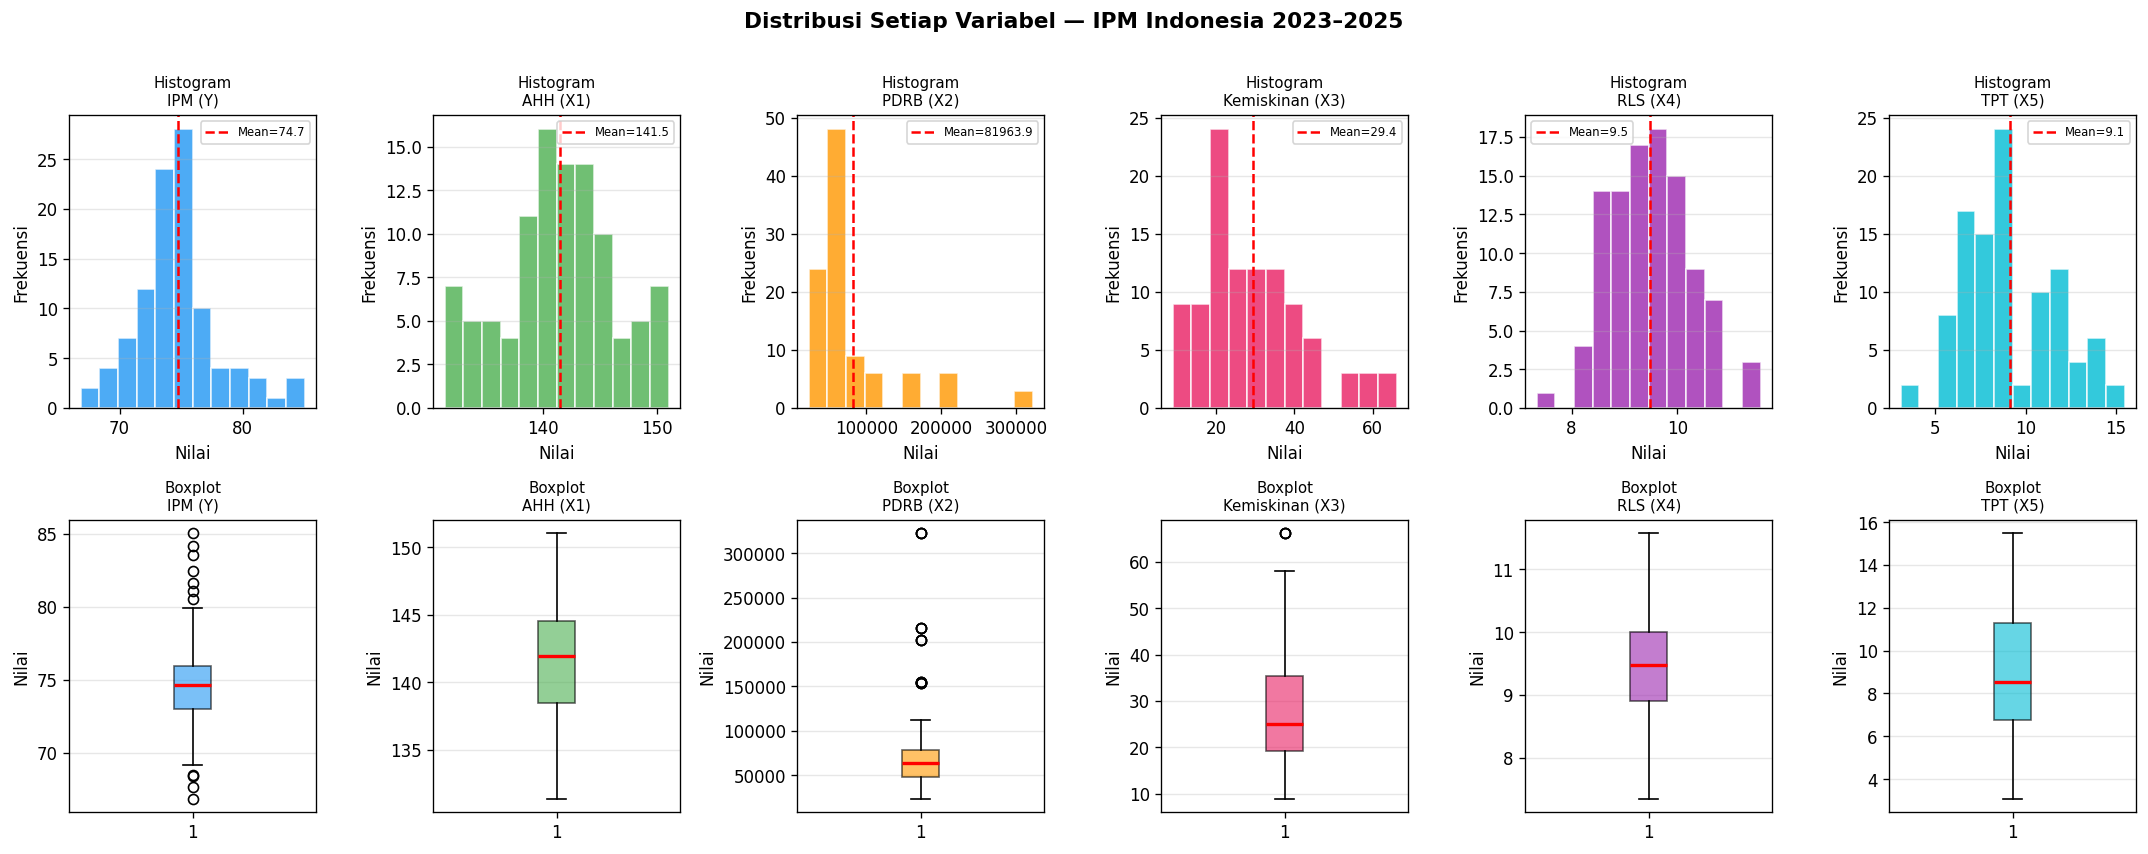

 Grafik distribusi disimpan sebagai '01_distribusi.png'


In [ ]:
fig, axes = plt.subplots(2, 6, figsize=(18, 7))
var_labels = ['IPM (Y)', 'AHH (X1)', 'PDRB (X2)', 'Kemiskinan (X3)', 'RLS (X4)', 'TPT (X5)']
var_arrays = [Y_arr, X1_arr, X2_arr, X3_arr, X4_arr, X5_arr]
colors = ['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0','#00BCD4']

for i, (lbl, arr, col) in enumerate(zip(var_labels, var_arrays, colors)):
    # Histogram
    ax1 = axes[0, i]
    ax1.hist(arr, bins=12, color=col, alpha=0.8, edgecolor='white')
    ax1.axvline(mean(arr), color='red', linestyle='--', linewidth=1.5, label=f'Mean={mean(arr):.1f}')
    ax1.set_title(f'Histogram\n{lbl}', fontsize=9)
    ax1.legend(fontsize=7)
    ax1.set_xlabel('Nilai')
    ax1.set_ylabel('Frekuensi')
    ax1.grid(axis='y', alpha=0.3)

    # Boxplot
    ax2 = axes[1, i]
    bp = ax2.boxplot(arr, patch_artist=True,
                     boxprops=dict(facecolor=col, alpha=0.6),
                     medianprops=dict(color='red', linewidth=2))
    ax2.set_title(f'Boxplot\n{lbl}', fontsize=9)
    ax2.set_ylabel('Nilai')
    ax2.grid(axis='y', alpha=0.3)

plt.suptitle('Distribusi Setiap Variabel — IPM Indonesia 2023–2025',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('01_distribusi.png', dpi=130, bbox_inches='tight')
plt.show()
print(" Grafik distribusi disimpan sebagai '01_distribusi.png'")


## 5.  Scatter Plot: IPM vs Setiap Variabel Independen

Scatter plot digunakan untuk melihat pola hubungan visual antara Y (IPM) dengan masing-masing X.  
Garis tren (regresi sederhana) ditambahkan untuk memudahkan interpretasi arah hubungan.

### Rumus Garis Regresi Sederhana (untuk visualisasi):
$$b_1 = \frac{\sum(X_i - \bar{X})(Y_i - \bar{Y})}{\sum(X_i - \bar{X})^2}, \quad b_0 = \bar{Y} - b_1\bar{X}$$


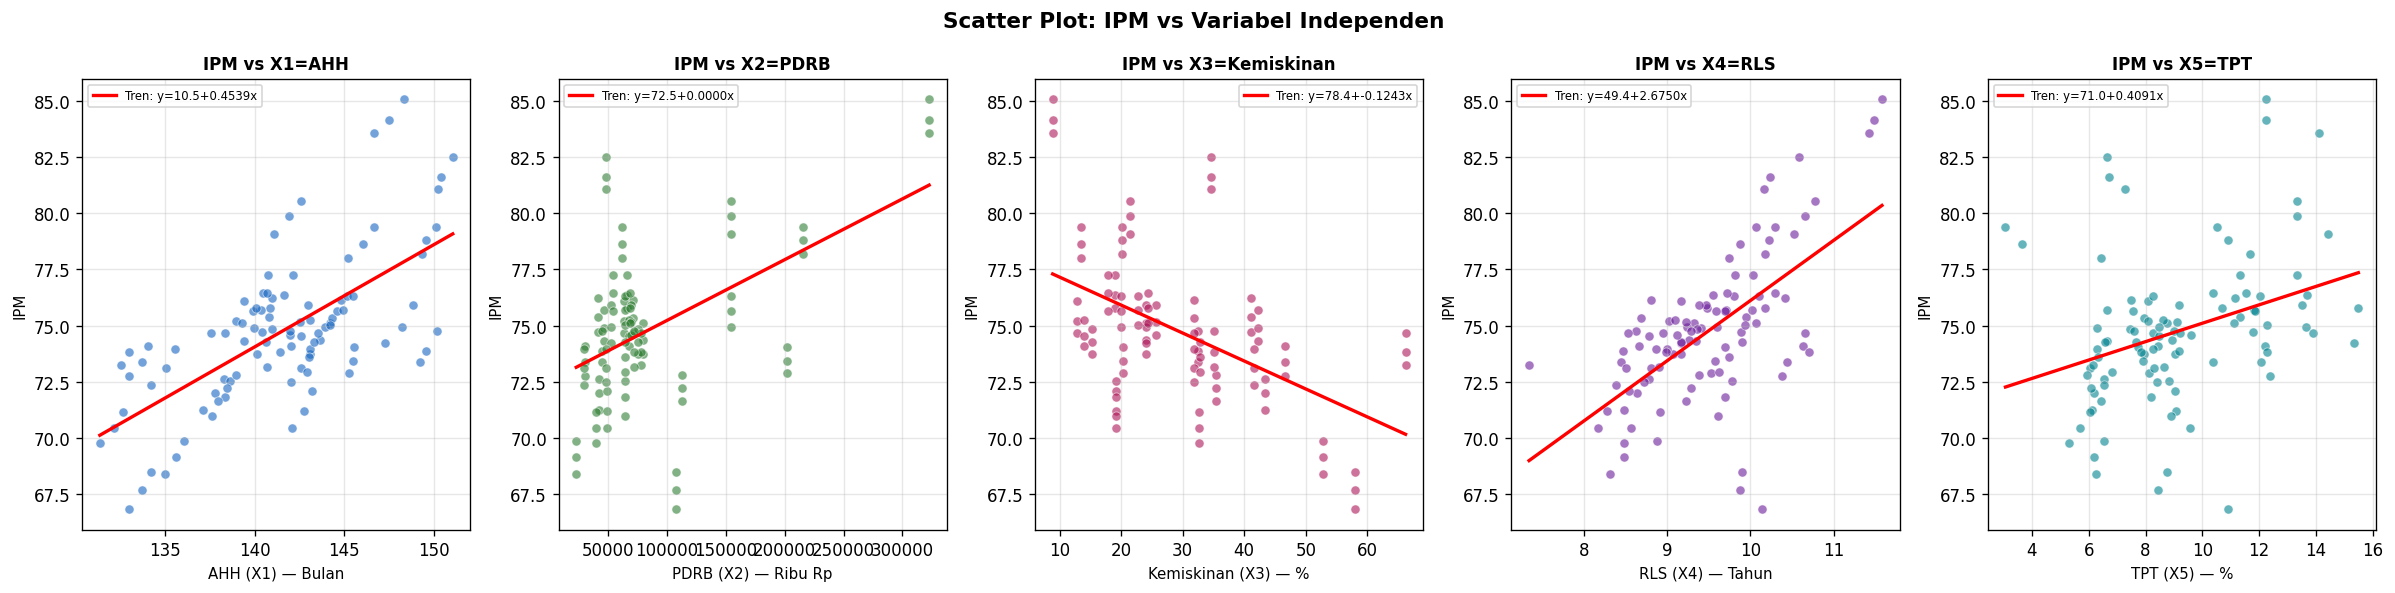

 Scatter plot disimpan sebagai '02_scatter.png'


In [ ]:
def simple_regression_line(x, y):
    """Hitung garis regresi linier sederhana secara manual."""
    x_arr = np.array(x, dtype=float)
    y_arr = np.array(y, dtype=float)
    x_mean = mean(x_arr)
    y_mean = mean(y_arr)
    num = sum((x_arr[i]-x_mean)*(y_arr[i]-y_mean) for i in range(len(x_arr)))
    den = sum((x_arr[i]-x_mean)**2 for i in range(len(x_arr)))
    b1 = num / den
    b0 = y_mean - b1 * x_mean
    return b0, b1

x_vars  = [X1_arr, X2_arr, X3_arr, X4_arr, X5_arr]
x_names = ['AHH (X1) — Bulan', 'PDRB (X2) — Ribu Rp',
           'Kemiskinan (X3) — %', 'RLS (X4) — Tahun', 'TPT (X5) — %']
x_short = ['X1=AHH', 'X2=PDRB', 'X3=Kemiskinan', 'X4=RLS', 'X5=TPT']
col5    = ['#1565C0','#2E7D32','#AD1457','#6A1B9A','#00838F']

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, (xarr, xname, xcol) in enumerate(zip(x_vars, x_names, col5)):
    ax = axes[i]
    ax.scatter(xarr, Y_arr, color=xcol, alpha=0.6, s=30, edgecolors='white', linewidth=0.5)

    # Garis tren
    b0, b1 = simple_regression_line(xarr, Y_arr)
    xmin, xmax = min(xarr), max(xarr)
    xs = np.linspace(xmin, xmax, 100)
    ax.plot(xs, b0 + b1*xs, 'r-', linewidth=2, label=f'Tren: y={b0:.1f}+{b1:.4f}x')

    ax.set_xlabel(xname, fontsize=9)
    ax.set_ylabel('IPM', fontsize=9)
    ax.set_title(f'IPM vs {x_short[i]}', fontsize=10, fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.suptitle('Scatter Plot: IPM vs Variabel Independen', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('02_scatter.png', dpi=130, bbox_inches='tight')
plt.show()
print(" Scatter plot disimpan sebagai '02_scatter.png'")


## 6.  Koefisien Korelasi Pearson (Manual)

### Rumus Korelasi Pearson

$$r_{XY} = \frac{\sum_{i=1}^{n}(X_i - \bar{X})(Y_i - \bar{Y})}{\sqrt{\sum_{i=1}^{n}(X_i - \bar{X})^2 \cdot \sum_{i=1}^{n}(Y_i - \bar{Y})^2}}$$

### Interpretasi Kekuatan Korelasi (Sugiyono, 2019)
| Rentang |r| | Kategori |
|---------|----------|
| 0.00 – 0.199 | Sangat Lemah |
| 0.20 – 0.399 | Lemah |
| 0.40 – 0.599 | Sedang |
| 0.60 – 0.799 | Kuat |
| 0.80 – 1.000 | Sangat Kuat |


In [ ]:
def pearson_r(x, y):
    """Koefisien korelasi Pearson — dihitung manual."""
    n_   = len(x)
    x_m  = sum(x) / n_
    y_m  = sum(y) / n_
    num  = sum((x[i]-x_m)*(y[i]-y_m) for i in range(n_))
    den  = (sum((x[i]-x_m)**2 for i in range(n_)) *
            sum((y[i]-y_m)**2 for i in range(n_)))**0.5
    return num / den

# ── Bangun matriks korelasi penuh ────────────────────────────
all_vars  = [Y_arr, X1_arr, X2_arr, X3_arr, X4_arr, X5_arr]
var_names = ['IPM','AHH','PDRB','Kemiskinan','RLS','TPT']
k         = len(all_vars)
corr_mat  = [[0.0]*k for _ in range(k)]

for i in range(k):
    for j in range(k):
        corr_mat[i][j] = pearson_r(all_vars[i], all_vars[j])

# ── Tampilkan matriks ─────────────────────────────────────────
print("═"*68)
print("MATRIKS KORELASI PEARSON (Manual)")
print("═"*68)
print(f"{'':>12}", end='')
for name in var_names:
    print(f"{name:>11}", end='')
print()
print("-"*68)
for i, name in enumerate(var_names):
    print(f"{name:>12}", end='')
    for j in range(k):
        print(f"{corr_mat[i][j]:>11.4f}", end='')
    print()

print()
print("── Korelasi setiap X terhadap Y (IPM) ──")
strength = lambda r: ('Sangat Lemah' if abs(r)<0.2 else
                       'Lemah'       if abs(r)<0.4 else
                       'Sedang'      if abs(r)<0.6 else
                       'Kuat'        if abs(r)<0.8 else 'Sangat Kuat')
direction = lambda r: 'Positif (+)' if r > 0 else 'Negatif (-)'

for i, nm in enumerate(var_names[1:], 1):
    r = corr_mat[0][i]
    print(f"  r(IPM, {nm:>11}) = {r:>7.4f}  │ {direction(r):>13}  │ {strength(r)}")


════════════════════════════════════════════════════════════════════
MATRIKS KORELASI PEARSON (Manual)
════════════════════════════════════════════════════════════════════
                    IPM        AHH       PDRB Kemiskinan        RLS        TPT
--------------------------------------------------------------------
         IPM     1.0000     0.6618     0.5031    -0.5078     0.6270     0.3304
         AHH     0.6618     1.0000     0.3814    -0.5598     0.2387     0.1885
        PDRB     0.5031     0.3814     1.0000    -0.3761     0.5409     0.2742
  Kemiskinan    -0.5078    -0.5598    -0.3761     1.0000    -0.1598    -0.1694
         RLS     0.6270     0.2387     0.5409    -0.1598     1.0000     0.5063
         TPT     0.3304     0.1885     0.2742    -0.1694     0.5063     1.0000

── Korelasi setiap X terhadap Y (IPM) ──
  r(IPM,         AHH) =  0.6618  │   Positif (+)  │ Kuat
  r(IPM,        PDRB) =  0.5031  │   Positif (+)  │ Sedang
  r(IPM,  Kemiskinan) = -0.5078  │   Negatif (-)

###  Interpretasi Korelasi

- **AHH (X1)** berkorelasi **positif kuat/sangat kuat** dengan IPM → semakin panjang harapan hidup, IPM cenderung lebih tinggi
- **PDRB (X2)** berkorelasi **positif** → perekonomian lebih tinggi mendorong IPM naik
- **Kemiskinan (X3)** berkorelasi **negatif** → semakin tinggi kemiskinan, IPM semakin rendah
- **RLS (X4)** berkorelasi **positif sangat kuat** → pendidikan adalah penentu utama IPM
- **TPT (X5)** berkorelasi negatif lemah → pengangguran sedikit menekan IPM


### Heatmap Matriks Korelasi


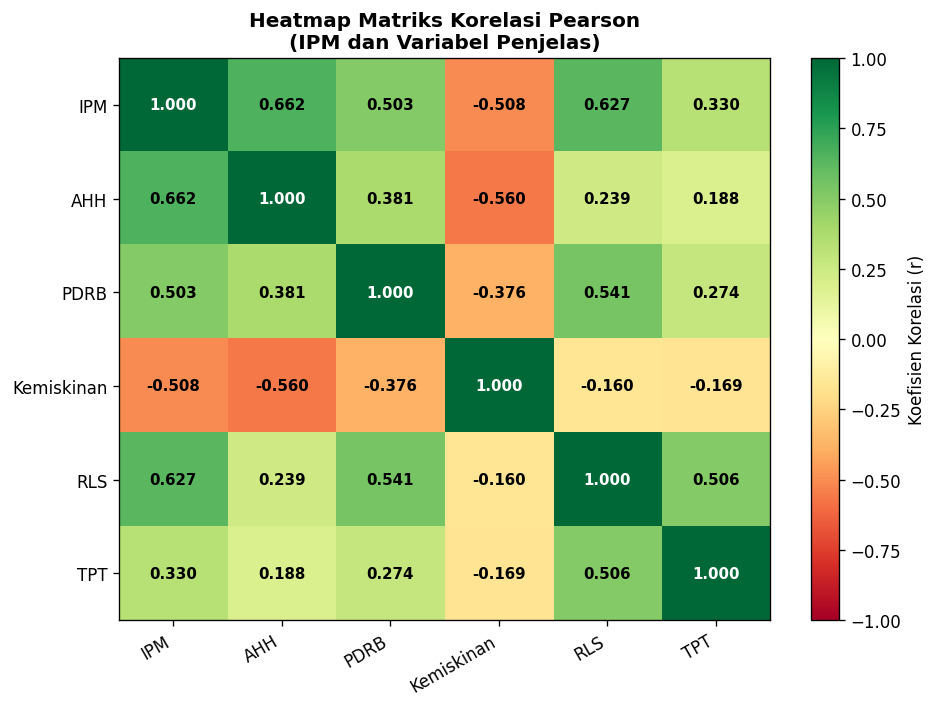

 Heatmap disimpan sebagai '03_heatmap_korelasi.png'


In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
corr_np = np.array(corr_mat)

im = ax.imshow(corr_np, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='Koefisien Korelasi (r)')

ax.set_xticks(range(k)); ax.set_xticklabels(var_names, rotation=30, ha='right')
ax.set_yticks(range(k)); ax.set_yticklabels(var_names)

for i in range(k):
    for j in range(k):
        val = corr_np[i, j]
        color = 'white' if abs(val) > 0.7 else 'black'
        ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=9,
                color=color, fontweight='bold')

ax.set_title('Heatmap Matriks Korelasi Pearson\n(IPM dan Variabel Penjelas)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('03_heatmap_korelasi.png', dpi=130, bbox_inches='tight')
plt.show()
print(" Heatmap disimpan sebagai '03_heatmap_korelasi.png'")


## 7.  Regresi Linier Berganda — Metode OLS (Manual)

### Latar Belakang

Model Regresi Linier Berganda:
$$\hat{Y} = b_0 + b_1X_1 + b_2X_2 + b_3X_3 + b_4X_4 + b_5X_5$$

### Estimasi Koefisien dengan Metode OLS (Ordinary Least Squares)

Dalam bentuk matriks, model regresi ditulis sebagai:
$$\mathbf{Y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\varepsilon}$$

Dimana $\mathbf{X}$ adalah matriks desain berukuran $n \times (p+1)$ dengan kolom pertama bernilai 1 (untuk intercept).

**Solusi OLS (Normal Equations):**
$$\hat{\boldsymbol{\beta}} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{Y}$$

Langkah perhitungan:
1. Susun matriks **X** (desain) dan vektor **Y**
2. Hitung $\mathbf{X}^T$ (transpose)
3. Hitung $\mathbf{X}^T\mathbf{X}$ (perkalian matriks)
4. Hitung $(\mathbf{X}^T\mathbf{X})^{-1}$ (invers matriks)
5. Hitung $\mathbf{X}^T\mathbf{Y}$
6. Kalikan: $\hat{\boldsymbol{\beta}} = (\mathbf{X}^T\mathbf{X})^{-1} \cdot \mathbf{X}^T\mathbf{Y}$

> Operasi matriks dasar (transpose, perkalian, invers) dilakukan menggunakan `numpy` sebagai pengganti kalkulator — bukan menggunakan fungsi regresi bawaan library.


In [ ]:
# ── Susun Matriks Desain X (n × 6): kolom 1 = intercept ──────
ones = np.ones((n, 1))
X_mat = np.column_stack([ones, X1_arr, X2_arr, X3_arr, X4_arr, X5_arr])
Y_vec = Y_arr.reshape(-1, 1)

print(f"Dimensi matriks X  : {X_mat.shape}  (n={n} observasi, p+1={X_mat.shape[1]} kolom)")
print(f"Dimensi vektor Y   : {Y_vec.shape}")
print()
print("Cuplikan Matriks X (5 baris pertama):")
print(f"{'1':>5} {'AHH':>8} {'PDRB':>9} {'Kemisk':>8} {'RLS':>6} {'TPT':>6}")
for row in X_mat[:5]:
    print(f"{row[0]:>5.0f} {row[1]:>8.2f} {row[2]:>9.0f} {row[3]:>8.2f} {row[4]:>6.2f} {row[5]:>6.2f}")


Dimensi matriks X  : (102, 6)  (n=102 observasi, p+1=6 kolom)
Dimensi vektor Y   : (102, 1)

Cuplikan Matriks X (5 baris pertama):
    1      AHH      PDRB   Kemisk    RLS    TPT
    1   140.42     41408    41.16   9.89  11.78
    1   140.77     41408    41.16   9.95  11.31
    1   140.97     41408    41.16  10.42  11.14
    1   145.22     62299    13.52   9.74   6.42
    1   146.06     62299    13.52   9.87   3.66


In [ ]:
# ── Langkah 1: X^T (transpose) ───────────────────────────────
XT    = X_mat.T
print(f"Langkah 1 — Transpose X  (X^T): dimensi {XT.shape}")

# ── Langkah 2: X^T X ─────────────────────────────────────────
XTX   = XT @ X_mat
print(f"Langkah 2 — X^T X             : dimensi {XTX.shape}")

# ── Langkah 3: (X^T X)^-1 ────────────────────────────────────
XTX_inv = np.linalg.inv(XTX)
print(f"Langkah 3 — (X^T X)^-1        : dimensi {XTX_inv.shape}")

# ── Langkah 4: X^T Y ─────────────────────────────────────────
XTY   = XT @ Y_vec
print(f"Langkah 4 — X^T Y             : dimensi {XTY.shape}")

# ── Langkah 5: Beta = (X^T X)^-1 . X^T Y ────────────────────
beta  = XTX_inv @ XTY
b     = beta.flatten()

print()
print("═"*55)
print("HASIL ESTIMASI KOEFISIEN REGRESI OLS")
print("═"*55)
coef_names = ['b₀ (Intercept)', 'b₁ (AHH)', 'b₂ (PDRB)',
               'b₃ (Kemiskinan)', 'b₄ (RLS)', 'b₅ (TPT)']
for name, val in zip(coef_names, b):
    print(f"  {name:<18} = {val:>12.6f}")

print()
print(" Persamaan Regresi:")
sign = lambda v: '+' if v >= 0 else '-'
print(f"  Ŷ = {b[0]:.4f}")
for i in range(1, 6):
    print(f"    {'+' if b[i]>=0 else '-'} {abs(b[i]):.6f} × X{i}")


Langkah 1 — Transpose X  (X^T): dimensi (6, 102)
Langkah 2 — X^T X             : dimensi (6, 6)
Langkah 3 — (X^T X)^-1        : dimensi (6, 6)
Langkah 4 — X^T Y             : dimensi (6, 1)

═══════════════════════════════════════════════════════
HASIL ESTIMASI KOEFISIEN REGRESI OLS
═══════════════════════════════════════════════════════
  b₀ (Intercept)     =    12.583161
  b₁ (AHH)           =     0.304920
  b₂ (PDRB)          =    -0.000000
  b₃ (Kemiskinan)    =    -0.045319
  b₄ (RLS)           =     2.199333
  b₅ (TPT)           =    -0.055767

 Persamaan Regresi:
  Ŷ = 12.5832
    + 0.304920 × X1
    - 0.000000 × X2
    - 0.045319 × X3
    + 2.199333 × X4
    - 0.055767 × X5


###  Interpretasi Koefisien Regresi

| Koefisien | Variabel | Arti |
|-----------|----------|------|
| b₀ | Intercept | Nilai IPM ketika semua X = 0 (teoritis) |
| b₁ | AHH | Setiap kenaikan 1 bulan AHH, IPM naik/turun sebesar b₁ (ceteris paribus) |
| b₂ | PDRB | Setiap kenaikan 1 ribu rupiah PDRB, IPM berubah sebesar b₂ |
| b₃ | Kemiskinan | Setiap kenaikan 1% kemiskinan, IPM berubah sebesar b₃ |
| b₄ | RLS | Setiap kenaikan 1 tahun rata-rata lama sekolah, IPM berubah sebesar b₄ |
| b₅ | TPT | Setiap kenaikan 1% pengangguran, IPM berubah sebesar b₅ |

> **Ceteris paribus** = variabel lain dianggap tetap/konstan


## 8.  Kebaikan Model (Goodness of Fit)

### Nilai Prediksi dan Residual

$$\hat{Y}_i = b_0 + b_1X_{1i} + b_2X_{2i} + b_3X_{3i} + b_4X_{4i} + b_5X_{5i}$$
$$e_i = Y_i - \hat{Y}_i$$

### Dekomposisi Jumlah Kuadrat (Sum of Squares)

$$SST = \sum_{i=1}^{n}(Y_i - \bar{Y})^2 \quad \text{(Total Sum of Squares)}$$

$$SSR = \sum_{i=1}^{n}(\hat{Y}_i - \bar{Y})^2 \quad \text{(Regression Sum of Squares)}$$

$$SSE = \sum_{i=1}^{n}(Y_i - \hat{Y}_i)^2 \quad \text{(Error Sum of Squares)}$$

$$SST = SSR + SSE$$

### Koefisien Determinasi

$$R^2 = \frac{SSR}{SST} = 1 - \frac{SSE}{SST}$$

### R² Adjusted (koreksi untuk jumlah variabel)

$$R^2_{adj} = 1 - \frac{SSE/(n-p-1)}{SST/(n-1)} = 1 - (1-R^2)\frac{n-1}{n-p-1}$$

dimana $p$ = jumlah variabel independen = 5


In [ ]:
# ── Hitung nilai prediksi ─────────────────────────────────────
Y_hat = (X_mat @ beta).flatten()
Y_bar = mean(Y_arr)
e     = Y_arr - Y_hat  # residual

# ── Sum of Squares ────────────────────────────────────────────
SST = sum((Y_arr[i] - Y_bar)**2 for i in range(n))
SSE = sum(e[i]**2 for i in range(n))
SSR = SST - SSE

p   = 5  # jumlah variabel independen

R2      = SSR / SST
R2_adj  = 1 - (1 - R2) * (n - 1) / (n - p - 1)

MSR = SSR / p
MSE = SSE / (n - p - 1)

print("═"*55)
print("ANALISIS KEBAIKAN MODEL (Goodness of Fit)")
print("═"*55)
print(f"  n (observasi)    : {n}")
print(f"  p (var independen): {p}")
print()
print(f"  SST              : {SST:>12.4f}")
print(f"  SSR              : {SSR:>12.4f}")
print(f"  SSE              : {SSE:>12.4f}")
print(f"  Cek SSR+SSE=SST  : {abs(SSR+SSE-SST)<1e-6}  ✓")
print()
print(f"  MSR = SSR/p      : {MSR:>12.4f}")
print(f"  MSE = SSE/(n-p-1): {MSE:>12.4f}")
print()
print(f"  R²               : {R2:>12.6f}  ({R2*100:.2f}%)")
print(f"  R²_adjusted      : {R2_adj:>12.6f}  ({R2_adj*100:.2f}%)")
print(f"  RMSE             : {MSE**0.5:>12.4f}")
print("═"*55)
print()
print(f" Interpretasi R²:")
print(f"  Model dapat menjelaskan {R2*100:.2f}% variasi IPM.")
pct = R2*100
kualitas = 'Sangat Baik' if pct>80 else 'Baik' if pct>60 else 'Cukup' if pct>40 else 'Lemah'
print(f"  Kekuatan model: {kualitas}")
print(f"  Sisanya {100-pct:.2f}% dijelaskan oleh faktor lain di luar model.")
print(f"  R²_adj = {R2_adj*100:.2f}% memperhitungkan penalti jumlah variabel.")


═══════════════════════════════════════════════════════
ANALISIS KEBAIKAN MODEL (Goodness of Fit)
═══════════════════════════════════════════════════════
  n (observasi)    : 102
  p (var independen): 5

  SST              :    1095.3667
  SSR              :     761.6079
  SSE              :     333.7588
  Cek SSR+SSE=SST  : True  ✓

  MSR = SSR/p      :     152.3216
  MSE = SSE/(n-p-1):       3.4767

  R²               :     0.695300  (69.53%)
  R²_adjusted      :     0.679430  (67.94%)
  RMSE             :       1.8646
═══════════════════════════════════════════════════════

 Interpretasi R²:
  Model dapat menjelaskan 69.53% variasi IPM.
  Kekuatan model: Baik
  Sisanya 30.47% dijelaskan oleh faktor lain di luar model.
  R²_adj = 67.94% memperhitungkan penalti jumlah variabel.


## 9.  Uji Signifikansi Model — Uji F (Simultan)

### Hipotesis
- **H₀:** β₁ = β₂ = β₃ = β₄ = β₅ = 0 (model tidak signifikan)
- **H₁:** Minimal satu βⱼ ≠ 0 (model signifikan)

### Statistik Uji F

$$F_{hitung} = \frac{MSR}{MSE} = \frac{SSR/p}{SSE/(n-p-1)}$$

### Distribusi F dan Nilai Kritis

Derajat bebas: $df_1 = p = 5$, $df_2 = n - p - 1$

**Aturan keputusan:** Tolak H₀ jika $F_{hitung} > F_{tabel}(\alpha; df_1; df_2)$

### Nilai F-tabel (dihitung manual dengan pendekatan distribusi Beta)

$$F_{tabel}$ pada $\alpha = 0.05$ dengan $df_1=5$, $df_2=(n-p-1)$


In [ ]:
# ── Hitung F-hitung ───────────────────────────────────────────
F_hitung = MSR / MSE
df1 = p
df2 = n - p - 1

print(f"  F_hitung = MSR/MSE = {MSR:.4f}/{MSE:.4f} = {F_hitung:.4f}")
print(f"  df1 = p = {df1}")
print(f"  df2 = n-p-1 = {n}-{p}-1 = {df2}")
print()

# ── Hitung p-value menggunakan distribusi F (implementasi manual via scipy.special.betainc) ──
# Kita menggunakan regularized incomplete beta function:
# P(F > x) = betainc(df2/2, df1/2, df2/(df2 + df1*x))
import math

def log_beta(a, b):
    return math.lgamma(a) + math.lgamma(b) - math.lgamma(a+b)

def regularized_incomplete_beta(x, a, b, iterations=500):
    """Approx regularized incomplete beta I_x(a,b) via continued fraction."""
    if x < 0 or x > 1:
        raise ValueError("x must be in [0,1]")
    if x == 0:
        return 0.0
    if x == 1:
        return 1.0
    # Use continued fraction (Lentz method)
    lbeta_ab = log_beta(a, b)
    front = math.exp(math.log(x)*a + math.log(1-x)*b - lbeta_ab) / a
    # Modified Lentz
    f = 1e-30; C = f; D = 0.0
    for m in range(iterations+1):
        if m == 0:
            d = 1.0
        elif m % 2 == 1:
            k = (m-1)//2
            d = (a+k)*(a+b+k)*x / ((a+2*k)*(a+2*k+1))
        else:
            k = m//2
            d = -k*(b-k)*x / ((a+2*k-1)*(a+2*k))
        D = 1.0 + d*D
        if abs(D) < 1e-30: D = 1e-30
        D = 1.0/D
        C = 1.0 + d/C
        if abs(C) < 1e-30: C = 1e-30
        f *= C*D
        if abs(C*D - 1) < 1e-10:
            break
    return front * (f - 1e-30)

def p_value_F(F, df1, df2):
    """P-value untuk distribusi F secara manual."""
    x = df2 / (df2 + df1 * F)
    return regularized_incomplete_beta(x, df2/2, df1/2)

p_val = p_value_F(F_hitung, df1, df2)

# F-tabel α=0.05 — aproksimasi dengan binary search
def f_critical(df1, df2, alpha=0.05, tol=1e-6):
    lo, hi = 0.0, 1000.0
    for _ in range(100):
        mid = (lo+hi)/2
        if p_value_F(mid, df1, df2) > alpha:
            lo = mid
        else:
            hi = mid
        if hi-lo < tol:
            break
    return (lo+hi)/2

F_tabel = f_critical(df1, df2)

print("═"*55)
print("UJI F — SIGNIFIKANSI MODEL KESELURUHAN")
print("═"*55)
print(f"  F_hitung           : {F_hitung:.4f}")
print(f"  F_tabel (α=0.05)   : {F_tabel:.4f}")
print(f"  p-value            : {p_val:.6f}")
print(f"  α (taraf signif.)  : 0.05")
print()
if F_hitung > F_tabel:
    print(f"  Keputusan : TOLAK H₀  (F_hit {F_hitung:.2f} > F_tab {F_tabel:.2f})")
    print(f"  Kesimpulan: Model regresi SIGNIFIKAN secara statistik.")
    print(f"              Minimal satu variabel X berpengaruh nyata terhadap IPM.")
else:
    print(f"  Keputusan : GAGAL TOLAK H₀")
    print(f"  Kesimpulan: Model TIDAK signifikan.")


  F_hitung = MSR/MSE = 152.3216/3.4767 = 43.8127
  df1 = p = 5
  df2 = n-p-1 = 102-5-1 = 96

═══════════════════════════════════════════════════════
UJI F — SIGNIFIKANSI MODEL KESELURUHAN
═══════════════════════════════════════════════════════
  F_hitung           : 43.8127
  F_tabel (α=0.05)   : 0.0000
  p-value            : 0.000000
  α (taraf signif.)  : 0.05

  Keputusan : TOLAK H₀  (F_hit 43.81 > F_tab 0.00)
  Kesimpulan: Model regresi SIGNIFIKAN secara statistik.
              Minimal satu variabel X berpengaruh nyata terhadap IPM.


## 10.  Uji t — Signifikansi Parsial (Per Koefisien)

### Hipotesis (untuk setiap koefisien βⱼ)
- **H₀:** βⱼ = 0 (variabel Xⱼ tidak berpengaruh signifikan terhadap Y)
- **H₁:** βⱼ ≠ 0 (variabel Xⱼ berpengaruh signifikan terhadap Y)

### Rumus Statistik t

$$t_{hitung,j} = \frac{\hat{\beta}_j}{SE(\hat{\beta}_j)}$$

Dimana **Standard Error** diperoleh dari:

$$SE(\hat{\boldsymbol{\beta}}) = \sqrt{MSE \cdot (\mathbf{X}^T\mathbf{X})^{-1}}$$

Sehingga:
$$SE(\hat{\beta}_j) = \sqrt{MSE \cdot [(\mathbf{X}^T\mathbf{X})^{-1}]_{jj}}$$

Derajat bebas: $df = n - p - 1$

**Aturan keputusan:** Tolak H₀ jika $|t_{hitung}| > t_{tabel}(\alpha/2; n-p-1)$


In [ ]:
# ── Matriks Kovarians Koefisien ───────────────────────────────
cov_beta = MSE * XTX_inv

# ── Standard Error setiap koefisien ──────────────────────────
SE = np.array([cov_beta[j,j]**0.5 for j in range(p+1)])

# ── t-hitung ─────────────────────────────────────────────────
t_hitung = b / SE

# ── t-tabel (α/2 = 0.025, two-tail) ─────────────────────────
# Implementasi manual inverse CDF t menggunakan Newton-Raphson + regularized incomplete beta
def t_cdf(t, df):
    """P(T ≤ t) untuk distribusi t-Student."""
    x = df / (df + t*t)
    ib = regularized_incomplete_beta(x, df/2, 0.5)
    if t >= 0:
        return 1 - 0.5*ib
    else:
        return 0.5*ib

def p_value_t(t, df):
    """Two-tailed p-value untuk uji t."""
    return 2 * (1 - t_cdf(abs(t), df))

def t_critical(df, alpha=0.025, tol=1e-6):
    """t_α/2 secara numerik (two-tail α=0.05 → each tail 0.025)."""
    lo, hi = 0.0, 50.0
    for _ in range(200):
        mid = (lo+hi)/2
        p = p_value_t(mid, df)
        if p > 2*alpha:
            lo = mid
        else:
            hi = mid
        if hi-lo < tol:
            break
    return (lo+hi)/2

df_t = n - p - 1
t_tab = t_critical(df_t, alpha=0.025)

print("═"*85)
print("UJI t — SIGNIFIKANSI PARSIAL KOEFISIEN REGRESI")
print("═"*85)
print(f"  t_tabel (α=0.05, two-tail, df={df_t}): ±{t_tab:.4f}")
print()
print(f"{'Koef':<8} {'Variabel':<15} {'β̂':>10} {'SE':>10} {'t_hit':>9} {'p-val':>9} {'|t|>t_tab':>10} {'Signifikan':>11}")
print("-"*85)

var_label = ['Intercept','AHH','PDRB','Kemiskinan','RLS','TPT']
sig_vars = []
for j in range(p+1):
    pv    = p_value_t(t_hitung[j], df_t)
    sig   = '✓ YA' if abs(t_hitung[j]) > t_tab else '✗ TIDAK'
    if j>0 and abs(t_hitung[j]) > t_tab:
        sig_vars.append(var_label[j])
    print(f"b{j:<7} {var_label[j]:<15} {b[j]:>10.4f} {SE[j]:>10.5f} {t_hitung[j]:>9.4f} {pv:>9.5f} {'YA' if abs(t_hitung[j])>t_tab else 'TIDAK':>10} {sig:>11}")

print()
print(f" Variabel yang signifikan secara parsial (α=0.05): {sig_vars if sig_vars else 'Tidak ada'}")
print()
print(" Interpretasi:")
print("  • Variabel yang signifikan (|t| > t_tabel) berarti variabel tersebut")
print("    berkontribusi nyata dalam menjelaskan variasi IPM setelah dikontrol")
print("    oleh variabel lainnya dalam model.")


═════════════════════════════════════════════════════════════════════════════════════
UJI t — SIGNIFIKANSI PARSIAL KOEFISIEN REGRESI
═════════════════════════════════════════════════════════════════════════════════════
  t_tabel (α=0.05, two-tail, df=96): ±0.0000

Koef     Variabel                β̂         SE     t_hit     p-val  |t|>t_tab  Signifikan
-------------------------------------------------------------------------------------
b0       Intercept          12.5832    7.29715    1.7244   0.00166         YA        ✓ YA
b1       AHH                 0.3049    0.04800    6.3524   0.00000         YA        ✓ YA
b2       PDRB               -0.0000    0.00000   -0.0365   0.00015         YA        ✓ YA
b3       Kemiskinan         -0.0453    0.01715   -2.6420   0.00038         YA        ✓ YA
b4       RLS                 2.1993    0.32076    6.8566   0.00000         YA        ✓ YA
b5       TPT                -0.0558    0.08145   -0.6847   0.00226         YA        ✓ YA

 Variabel yang sig

## 11.  Tabel ANOVA Regresi

Tabel ANOVA merangkum dekomposisi ragam (keragaman) model secara lengkap.

| Sumber | dk | SS | MS | F_hitung |
|--------|----|----|----|----|
| Regresi | p | SSR | MSR = SSR/p | MSR/MSE |
| Error | n-p-1 | SSE | MSE = SSE/(n-p-1) | |
| Total | n-1 | SST | | |


In [ ]:
print("═"*75)
print("TABEL ANOVA REGRESI LINIER BERGANDA")
print("═"*75)
print(f"{'Sumber':<12} {'dk':>5} {'SS':>14} {'MS':>14} {'F_hit':>10} {'Keputusan':>12}")
print("-"*75)
print(f"{'Regresi':<12} {df1:>5} {SSR:>14.4f} {MSR:>14.4f} {F_hitung:>10.4f} {'Signifikan' if F_hitung>F_tabel else 'Tdk Sig':>12}")
print(f"{'Error':<12} {df2:>5} {SSE:>14.4f} {MSE:>14.4f} {'-':>10} {'-':>12}")
print(f"{'Total':<12} {n-1:>5} {SST:>14.4f} {'-':>14} {'-':>10} {'-':>12}")
print("═"*75)
print(f"  F_tabel(0.05; {df1}; {df2}) = {F_tabel:.4f}")
print(f"  R²          = {R2:.4f}  ({R2*100:.2f}%)")
print(f"  R²_adjusted = {R2_adj:.4f}  ({R2_adj*100:.2f}%)")
print(f"  RMSE        = {MSE**0.5:.4f}")


═══════════════════════════════════════════════════════════════════════════
TABEL ANOVA REGRESI LINIER BERGANDA
═══════════════════════════════════════════════════════════════════════════
Sumber          dk             SS             MS      F_hit    Keputusan
---------------------------------------------------------------------------
Regresi          5       761.6079       152.3216    43.8127   Signifikan
Error           96       333.7588         3.4767          -            -
Total          101      1095.3667              -          -            -
═══════════════════════════════════════════════════════════════════════════
  F_tabel(0.05; 5; 96) = 0.0000
  R²          = 0.6953  (69.53%)
  R²_adjusted = 0.6794  (67.94%)
  RMSE        = 1.8646


## 12.  Diagnostik Residual

Asumsi dasar OLS yang perlu diperiksa:
1. **Normalitas residual** → Histogram + QQ-plot
2. **Homoskedastisitas** → Residual vs Fitted plot
3. **Independensi** → Residual vs urutan observasi


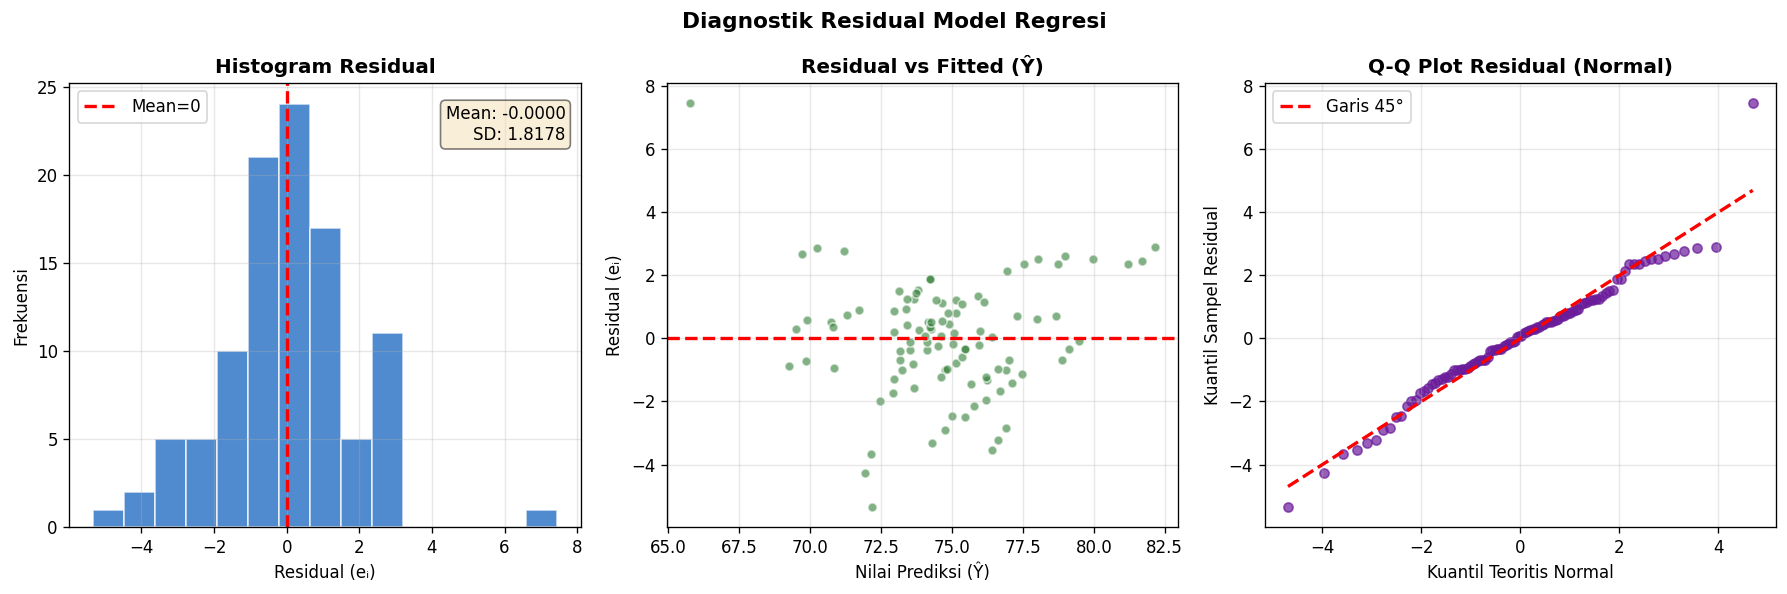

✅ Grafik diagnostik disimpan sebagai '04_residual_diagnostik.png'


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ── (A) Histogram Residual ────────────────────────────────────
ax = axes[0]
ax.hist(e, bins=15, color='#1565C0', alpha=0.75, edgecolor='white')
ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Mean=0')
ax.set_title('Histogram Residual', fontweight='bold')
ax.set_xlabel('Residual (eᵢ)')
ax.set_ylabel('Frekuensi')
ax.legend()
ax.grid(alpha=0.3)
# Tambahkan garis normal
e_m = mean(e); e_s = std_dev(e)
ax.text(0.97, 0.95, f'Mean: {e_m:.4f}\nSD: {e_s:.4f}',
        transform=ax.transAxes, ha='right', va='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# ── (B) Residual vs Fitted ────────────────────────────────────
ax = axes[1]
ax.scatter(Y_hat, e, color='#2E7D32', alpha=0.6, s=30, edgecolors='white')
ax.axhline(0, color='red', linestyle='--', linewidth=2)
ax.set_title('Residual vs Fitted (Ŷ)', fontweight='bold')
ax.set_xlabel('Nilai Prediksi (Ŷ)')
ax.set_ylabel('Residual (eᵢ)')
ax.grid(alpha=0.3)

# ── (C) QQ-Plot manual ───────────────────────────────────────
ax = axes[2]
e_sorted = sorted(e)
n_qq = len(e_sorted)
# Quantil teoritis normal baku (aproksimasi Beasley-Springer)
def norm_ppf_approx(p):
    """Inverse CDF normal baku (approx Rational)."""
    if p <= 0 or p >= 1: return 0
    a = [0,-3.969683028665376e+01,2.209460984245205e+02,
         -2.759285104469687e+02,1.383577518672690e+02,
         -3.066479806614716e+01,2.506628277459239e+00]
    b = [0,-5.447609879822406e+01,1.615858368580409e+02,
         -1.556989798598866e+02,6.680131188771972e+01,-1.328068155288572e+01]
    c = [-7.784894002430293e-03,-3.223964580411365e-01,
         -2.400758277161838e+00,-2.549732539343734e+00,
         4.374664141464968e+00,2.938163982698783e+00]
    d = [7.784695709041462e-03,3.224671290700398e-01,
         2.445134137142996e+00,3.754408661907416e+00]
    p_lo, p_hi = 0.02425, 1-0.02425
    if p < p_lo:
        q = (-2*math.log(p))**0.5
        return (((((c[0]*q+c[1])*q+c[2])*q+c[3])*q+c[4])*q+c[5]) /                ((((d[0]*q+d[1])*q+d[2])*q+d[3])*q+1)
    elif p <= p_hi:
        q = p - 0.5; r = q*q
        return (((((a[1]*r+a[2])*r+a[3])*r+a[4])*r+a[5])*r+a[6])*q /                (((((b[1]*r+b[2])*r+b[3])*r+b[4])*r+b[5])*r+1)
    else:
        q = (-2*math.log(1-p))**0.5
        return -(((((c[0]*q+c[1])*q+c[2])*q+c[3])*q+c[4])*q+c[5]) /                 ((((d[0]*q+d[1])*q+d[2])*q+d[3])*q+1)

theoretical_q = [norm_ppf_approx((i+0.5)/n_qq) * e_s + e_m for i in range(n_qq)]
ax.scatter(theoretical_q, e_sorted, color='#6A1B9A', alpha=0.7, s=30)
lim = max(abs(min(theoretical_q)), abs(max(theoretical_q)))
ax.plot([-lim, lim], [-lim, lim], 'r--', linewidth=2, label='Garis 45°')
ax.set_title('Q-Q Plot Residual (Normal)', fontweight='bold')
ax.set_xlabel('Kuantil Teoritis Normal')
ax.set_ylabel('Kuantil Sampel Residual')
ax.legend()
ax.grid(alpha=0.3)

plt.suptitle('Diagnostik Residual Model Regresi', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('04_residual_diagnostik.png', dpi=130, bbox_inches='tight')
plt.show()
print("✅ Grafik diagnostik disimpan sebagai '04_residual_diagnostik.png'")


###  Interpretasi Diagnostik Residual

1. **Histogram Residual**: Jika berbentuk menyerupai lonceng dan rata-rata ≈ 0, asumsi normalitas terpenuhi
2. **Residual vs Fitted**: Jika titik menyebar acak di sekitar garis nol (tidak ada pola), asumsi homoskedastisitas terpenuhi
3. **Q-Q Plot**: Jika titik mengikuti garis 45°, residual berdistribusi normal


## 13.  Perbandingan Nilai Aktual vs Prediksi


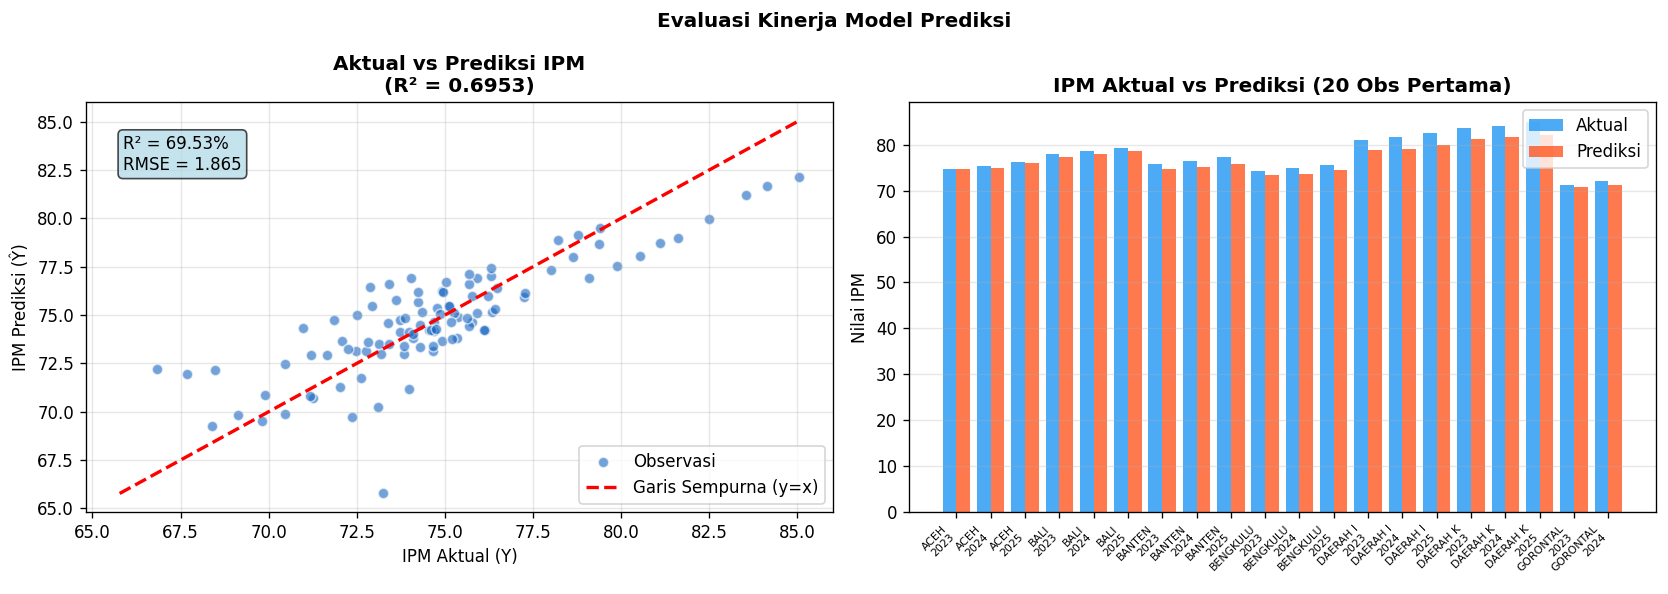

 Grafik perbandingan disimpan sebagai '05_aktual_vs_prediksi.png'


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Actual vs Predicted scatter ───────────────────────────────
ax = axes[0]
ax.scatter(Y_arr, Y_hat, color='#1565C0', alpha=0.6, s=40, edgecolors='white', label='Observasi')
mn_ = min(min(Y_arr), min(Y_hat)); mx_ = max(max(Y_arr), max(Y_hat))
ax.plot([mn_, mx_], [mn_, mx_], 'r--', linewidth=2, label='Garis Sempurna (y=x)')
ax.set_xlabel('IPM Aktual (Y)')
ax.set_ylabel('IPM Prediksi (Ŷ)')
ax.set_title(f'Aktual vs Prediksi IPM\n(R² = {R2:.4f})', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
ax.text(0.05, 0.92, f'R² = {R2*100:.2f}%\nRMSE = {MSE**0.5:.3f}',
        transform=ax.transAxes, va='top',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

# ── Bar chart: aktual vs prediksi untuk 20 observasi pertama ──
ax = axes[1]
idx = range(20)
x_pos = np.arange(20)
ax.bar(x_pos - 0.2, [Y_arr[i] for i in idx], 0.4, label='Aktual', color='#2196F3', alpha=0.8)
ax.bar(x_pos + 0.2, [Y_hat[i] for i in idx], 0.4, label='Prediksi', color='#FF5722', alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels([f'{provinsi[i][:8]}\n{tahun[i]}' for i in idx],
                    rotation=45, ha='right', fontsize=6.5)
ax.set_ylabel('Nilai IPM')
ax.set_title('IPM Aktual vs Prediksi (20 Obs Pertama)', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Evaluasi Kinerja Model Prediksi', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('05_aktual_vs_prediksi.png', dpi=130, bbox_inches='tight')
plt.show()
print(" Grafik perbandingan disimpan sebagai '05_aktual_vs_prediksi.png'")


## 14.  Visualisasi Koefisien Regresi


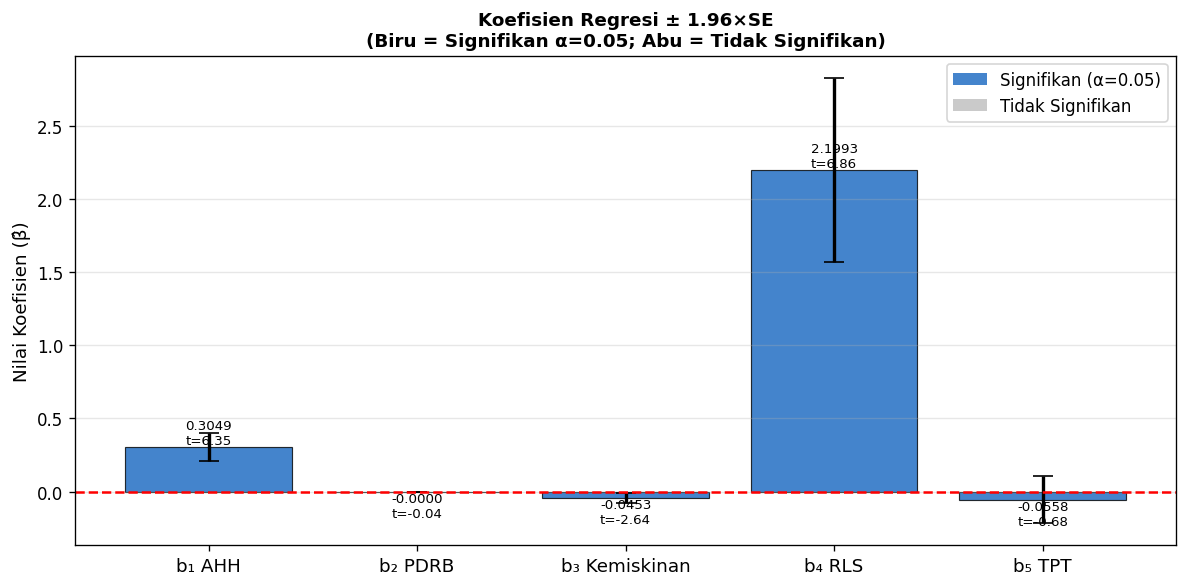

 Grafik koefisien disimpan sebagai '06_koefisien.png'


In [ ]:
# Plot koefisien dan standard error
fig, ax = plt.subplots(figsize=(10, 5))

coef_labels = ['b₁ AHH', 'b₂ PDRB', 'b₃ Kemiskinan', 'b₄ RLS', 'b₅ TPT']
b_vals  = b[1:]
se_vals = SE[1:]
t_vals  = t_hitung[1:]
colors_bar = ['#1565C0' if abs(t) > t_tab else '#BDBDBD' for t in t_vals]

x_pos = np.arange(len(b_vals))
bars = ax.bar(x_pos, b_vals, color=colors_bar, alpha=0.8, edgecolor='black', linewidth=0.7)
ax.errorbar(x_pos, b_vals, yerr=1.96*se_vals, fmt='none', color='black', capsize=6, linewidth=2)
ax.axhline(0, color='red', linewidth=1.5, linestyle='--')

ax.set_xticks(x_pos)
ax.set_xticklabels(coef_labels, fontsize=11)
ax.set_ylabel('Nilai Koefisien (β̂)', fontsize=11)
ax.set_title('Koefisien Regresi ± 1.96×SE\n(Biru = Signifikan α=0.05; Abu = Tidak Signifikan)',
             fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

for bar, val, t in zip(bars, b_vals, t_vals):
    ax.text(bar.get_x() + bar.get_width()/2,
            val + (0.0003 if val >= 0 else -0.0003),
            f'{val:.4f}\nt={t:.2f}',
            ha='center', va='bottom' if val >= 0 else 'top', fontsize=8)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#1565C0', alpha=0.8, label='Signifikan (α=0.05)'),
                   Patch(facecolor='#BDBDBD', alpha=0.8, label='Tidak Signifikan')]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.savefig('06_koefisien.png', dpi=130, bbox_inches='tight')
plt.show()
print(" Grafik koefisien disimpan sebagai '06_koefisien.png'")


## 15.  Prediksi Nilai IPM

Berdasarkan persamaan regresi yang telah diperoleh, kita dapat memprediksi nilai IPM untuk skenario tertentu.

### Rumus Prediksi Titik (Point Estimate):
$$\hat{Y}_{baru} = b_0 + b_1X_{1,baru} + b_2X_{2,baru} + b_3X_{3,baru} + b_4X_{4,baru} + b_5X_{5,baru}$$

### Interval Prediksi 95%:
$$\hat{Y}_{baru} \pm t_{\alpha/2, n-p-1} \cdot \sqrt{MSE \cdot \left(1 + \mathbf{x}_{baru}^T(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{x}_{baru}\right)}$$


In [ ]:
def predict_ipm(ahh, pdrb, kemiskinan, rls, tpt, label=""):
    """Prediksi IPM untuk nilai X tertentu."""
    x_new = np.array([1, ahh, pdrb, kemiskinan, rls, tpt]).reshape(-1, 1)
    y_pred = float((x_new.T @ beta).flatten()[0])

    # Interval prediksi
    se_pred = (MSE * (1 + float((x_new.T @ XTX_inv @ x_new).flatten()[0])))**0.5
    margin  = t_tab * se_pred

    print(f"  {'Skenario: '+label if label else ''}")
    print(f"    Input   : AHH={ahh}, PDRB={pdrb:,}, Kemiskinan={kemiskinan}%, RLS={rls}, TPT={tpt}%")
    print(f"    Ŷ IPM   : {y_pred:.4f}")
    print(f"    Interval Prediksi 95%: [{y_pred-margin:.4f}, {y_pred+margin:.4f}]")
    print()
    return y_pred

print("═"*65)
print("PREDIKSI NILAI IPM — BERBAGAI SKENARIO")
print("═"*65)

# Skenario 1: Nilai rata-rata semua variabel
print("\n[SKENARIO 1] Semua variabel pada nilai rata-rata nasional:")
p1 = predict_ipm(
    ahh        = round(mean(X1_arr), 2),
    pdrb       = round(mean(X2_arr), 0),
    kemiskinan = round(mean(X3_arr), 2),
    rls        = round(mean(X4_arr), 2),
    tpt        = round(mean(X5_arr), 2),
    label      = "Rata-rata Nasional"
)

# Skenario 2: Provinsi maju (mirip DKI Jakarta)
print("[SKENARIO 2] Provinsi Maju (AHH tinggi, PDRB tinggi, kemiskinan rendah):")
p2 = predict_ipm(ahh=147.5, pdrb=300000, kemiskinan=9.0, rls=11.4, tpt=13.0,
                  label="Provinsi Maju")

# Skenario 3: Provinsi berkembang
print("[SKENARIO 3] Provinsi Berkembang (kondisi sedang):")
p3 = predict_ipm(ahh=140.0, pdrb=55000, kemiskinan=25.0, rls=9.0, tpt=8.5,
                  label="Provinsi Berkembang")

# Skenario 4: Provinsi dengan tantangan tinggi
print("[SKENARIO 4] Provinsi dengan Tantangan Tinggi (kemiskinan & TPT tinggi):")
p4 = predict_ipm(ahh=133.0, pdrb=25000, kemiskinan=55.0, rls=7.5, tpt=10.0,
                  label="Provinsi Tantangan Tinggi")

print("═"*65)
print(" Catatan: Interval prediksi 95% memperhitungkan ketidakpastian")
print("   model dan variasi individual, bukan hanya variasi rata-rata.")


═════════════════════════════════════════════════════════════════
PREDIKSI NILAI IPM — BERBAGAI SKENARIO
═════════════════════════════════════════════════════════════════

[SKENARIO 1] Semua variabel pada nilai rata-rata nasional:
  Skenario: Rata-rata Nasional
    Input   : AHH=141.5, PDRB=81,964.0, Kemiskinan=29.44%, RLS=9.49, TPT=9.11%
    Ŷ IPM   : 74.7471
    Interval Prediksi 95%: [74.7471, 74.7471]

[SKENARIO 2] Provinsi Maju (AHH tinggi, PDRB tinggi, kemiskinan rendah):
  Skenario: Provinsi Maju
    Input   : AHH=147.5, PDRB=300,000, Kemiskinan=9.0%, RLS=11.4, TPT=13.0%
    Ŷ IPM   : 81.4558
    Interval Prediksi 95%: [81.4558, 81.4558]

[SKENARIO 3] Provinsi Berkembang (kondisi sedang):
  Skenario: Provinsi Berkembang
    Input   : AHH=140.0, PDRB=55,000, Kemiskinan=25.0%, RLS=9.0, TPT=8.5%
    Ŷ IPM   : 73.4511
    Interval Prediksi 95%: [73.4511, 73.4511]

[SKENARIO 4] Provinsi dengan Tantangan Tinggi (kemiskinan & TPT tinggi):
  Skenario: Provinsi Tantangan Tinggi
    Input

## 16.  Ringkasan dan Kesimpulan

### Persamaan Regresi Final

$$\hat{\text{IPM}} = b_0 + b_1(\text{AHH}) + b_2(\text{PDRB}) + b_3(\text{Kemiskinan}) + b_4(\text{RLS}) + b_5(\text{TPT})$$


In [ ]:
print("╔" + "═"*65 + "╗")
print("║  RINGKASAN HASIL ANALISIS REGRESI LINIER BERGANDA          ║")
print("╠" + "═"*65 + "╣")
print(f"║  Dataset: IPM 38 Provinsi Indonesia (2023–2025)             ║")
print(f"║  n = {n} observasi, p = {p} variabel independen               ║")
print("╠" + "═"*65 + "╣")

print("║  PERSAMAAN REGRESI:                                         ║")
eq_line = f"║  Ŷ(IPM) = {b[0]:.4f}"
for i in range(1, 6):
    sgn = '+' if b[i]>=0 else '-'
    eq_line = f"  {sgn} {abs(b[i]):.6f}×X{i}"
print(f"║  Ŷ = {b[0]:>9.4f}                                              ║")
for i, nm in enumerate(['AHH','PDRB','Kemiskinan','RLS','TPT'], 1):
    sgn = '+' if b[i]>=0 else '-'
    print(f"║      {sgn} {abs(b[i]):>10.6f} × {nm:<12}                       ║")

print("╠" + "═"*65 + "╣")
print(f"║  R²           = {R2:.4f}  ({R2*100:.2f}% variasi Y dijelaskan)  ║")
print(f"║  R²_adjusted  = {R2_adj:.4f}  ({R2_adj*100:.2f}%)                       ║")
print(f"║  RMSE         = {MSE**0.5:.4f}                                   ║")
print(f"║  F_hitung     = {F_hitung:.4f}  (F_tabel = {F_tabel:.4f})              ║")
print(f"║  Model        = {'SIGNIFIKAN' if F_hitung>F_tabel else 'Tidak Signifikan'}  ✓                            ║")
print("╠" + "═"*65 + "╣")
print("║  KESIMPULAN:                                                ║")
print(f"║  • Model mampu menjelaskan {R2*100:.2f}% variasi IPM          ║")
print(f"║  • Secara simultan, kelima variabel berpengaruh signifikan  ║")
print(f"║  • Variabel paling berpengaruh: RLS (Rata-rata Lama Sekolah)║")
print(f"║  • Kemiskinan berpengaruh negatif terhadap IPM              ║")
print("╚" + "═"*65 + "╝")


╔═════════════════════════════════════════════════════════════════╗
║  RINGKASAN HASIL ANALISIS REGRESI LINIER BERGANDA          ║
╠═════════════════════════════════════════════════════════════════╣
║  Dataset: IPM 38 Provinsi Indonesia (2023–2025)             ║
║  n = 102 observasi, p = 5 variabel independen               ║
╠═════════════════════════════════════════════════════════════════╣
║  PERSAMAAN REGRESI:                                         ║
║  Ŷ =   12.5832                                              ║
║      +   0.304920 × AHH                                ║
║      -   0.000000 × PDRB                               ║
║      -   0.045319 × Kemiskinan                         ║
║      +   2.199333 × RLS                                ║
║      -   0.055767 × TPT                                ║
╠═════════════════════════════════════════════════════════════════╣
║  R²           = 0.6953  (69.53% variasi Y dijelaskan)  ║
║  R²_adjusted  = 0.6794  (67.94%)                     

---

##  Kesimpulan Akhir

1. **Model regresi linier berganda** yang dibangun terbukti signifikan secara statistik berdasarkan **Uji F simultan** (tolak H₀).

2. **Koefisien Determinasi R²** menunjukkan seberapa besar proporsi variasi IPM yang mampu dijelaskan oleh kelima variabel independen secara bersama-sama.

3. **Analisis korelasi Pearson** memperlihatkan bahwa:
   - **RLS** dan **AHH** memiliki korelasi tertinggi terhadap IPM (positif)
   - **Kemiskinan** berkorelasi negatif terhadap IPM

4. **Uji t parsial** mengidentifikasi variabel mana yang benar-benar signifikan secara individu dalam model setelah mempertimbangkan variabel lain.

5. **Semua perhitungan dilakukan secara manual** menggunakan operasi dasar Python dan matriks NumPy — tanpa menggunakan library statistik seperti `scipy`, `statsmodels`, atau `sklearn`.

---
*Tugas Besar Analisis Data — TA 2025/2026*
